In [1]:
"""
Sigma(E) and M(E) Non-Hermiticity Analysis with respect to condition numbers
===================================
Loads Sigma matrices for indices 95-105, computes non-Hermiticity metrics,
and plots how they evolve across energy index.
Run cell by cell in Jupyter.
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

folder = Path("/scratch/yimili/matrices")
name       = "carbon-nanotube"   # <-- change to "carbon-chain" or "carbon-nanotube"
indices    = list(range(0, 402))  # 95 to 105 inclusive
idx_arr = np.array(indices)

offset2 = 0.005
res = 0.005

energies = -4.6 - offset2 + res*idx_arr.astype(float)
print(energies[-1])

-2.5999999999999996


In [2]:
# ---------------------------------------------------------------------------
# Load all Sigma matrices
# ---------------------------------------------------------------------------

"""
sigmas = {}
for idx in indices:
    path = folder / name / f"Sigma_E_{idx}.npy"
    sigmas[idx] = np.load(path)
"""

# ---------------------------------------------------------------------------
# Load all M(E) matrices
# ---------------------------------------------------------------------------
M = {}
for idx in indices:
    path = folder / name / f"M_E_{idx}.npy"
    M[idx] = np.load(path)


In [3]:
# ---------------------------------------------------------------------------
# Helper: compute all metrics
# ---------------------------------------------------------------------------
def hermitian_metrics(A):
    frob_A = np.linalg.norm(A, 'fro')
    n = A.shape[0]
    Ah = A.conj().T
    # Hermitian and anti-Hermitian parts
    H_part  = (A + Ah) / 2          # Hermitian part  (real energy shift)
    K_part  = (A - Ah) / (2j)       # anti-Hermitian part, also Hermitian matrix
    # 1. Max absolute deviation from Hermitian
    diff         = A - Ah
    max_dev      = np.max(np.abs(diff))
    rel_dev      = max_dev / (frob_A + 1e-300)
    # 2. Frobenius norm of anti-Hermitian part
    frob_antiherm = np.linalg.norm(diff, 'fro') / 2
    # 2b. Diagonal contribution to anti-Hermiticity
    diag_antiherm      = np.diag(np.diag(diff) / 2)
    frob_diag_antiherm = np.linalg.norm(diag_antiherm, 'fro')
    diag_ratio         = frob_diag_antiherm / (frob_antiherm + 1e-300)
    # 3. Eigenvalues of A itself (+ eigenvectors for kappa_V)
    w_A, V_A     = np.linalg.eig(A) #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!EXPENSIVE!!!!!!!!!!!!!!!!!!!!
    # 3b. imaginary parts of the eigenvalues
    min_abs_A_imag    = np.min(np.abs(w_A.imag))
    max_abs_A_imag    = np.max(np.abs(w_A.imag))
    # 3c. Eigenvector condition number  (non-normality / pseudospectrum diagnostic)
    kappa_V      = np.linalg.cond(V_A)
    # 3d. Henrici's departure from normality (basis-independent)
    dep_norm     = np.sqrt(max(frob_A**2 - np.sum(np.abs(w_A)**2), 0.0))
    dep_norm_rel = dep_norm / (frob_A + 1e-300)
    # 3e. Smallest |eigenvalue|  (upper bound on σ_min; combined with stored σ_min downstream)
    min_abs_eig  = np.min(np.abs(w_A))
    # 4. Eigenvalues of K (the broadening operator) — these are the Lorentzian widths
    w_K          = np.zeros(K_part.shape[0], dtype=complex)
    min_abs_K    = np.min(np.abs(w_K))
    max_abs_K    = np.max(np.abs(w_K))
    # 5. Eigenvalues of H (the real energy shift)
    w_H          = np.zeros(H_part.shape[0], dtype=complex)
    min_abs_H    = np.min(np.abs(w_H))
    max_abs_H    = np.max(np.abs(w_H))
    # 6. Non-normality: ||AA† - A†A||_F  (zero iff A is normal)
    comm         = A @ Ah - Ah @ A
    non_normality = np.linalg.norm(comm, 'fro') / (frob_A**2 + 1e-300)
    # 7. Ratio of anti-Hermitian to Hermitian spectral weight
    norm_H       = np.linalg.norm(H_part, 'fro')
    norm_K       = np.linalg.norm(K_part, 'fro')
    ratio_KH     = norm_K / (norm_H + 1e-300)
    
    return {
        "frob_A":             frob_A,
        "max_dev":            max_dev,
        "rel_dev":            rel_dev,
        "frob_antiherm":      frob_antiherm,
        "frob_diag_antiherm": frob_diag_antiherm,
        "diag_ratio":         diag_ratio,
        "w_A":                w_A,
        "min_abs_A_imag":     min_abs_A_imag,
        "max_abs_A_imag":     max_abs_A_imag,
        "kappa_V":            kappa_V,
        "dep_norm":           dep_norm,
        "dep_norm_rel":       dep_norm_rel,
        "min_abs_eig":        min_abs_eig,
        "w_K":                w_K,
        "min_abs_K":          min_abs_K,
        "max_abs_K":          max_abs_K,
        "w_H":                w_H,
        "min_abs_H":          min_abs_H,
        "max_abs_H":          max_abs_H,
        "non_normality":      non_normality,
        "norm_H":             norm_H,
        "norm_K":             norm_K,
        "ratio_KH":           ratio_KH,
        "H_part":             H_part,
        "K_part":             K_part,
    }

In [4]:
# ---------------------------------------------------------------------------
# Compute metrics for all indices
# ---------------------------------------------------------------------------

metrics = {idx: hermitian_metrics(M[idx]) for idx in indices}


In [ ]:

# ---------------------------------------------------------------------------
# Print table
# ---------------------------------------------------------------------------

print(f"\n{'='*90}")
print(f"{'idx':>5}  {'max_dev':>12}  {'rel_dev':>10}  {'frob_AH':>10}  {'min|A_eig|':>12}  {'max|A_eig|':>12}  {'non_norm':>12}  {'ratio_K/H':>10}")
print(f"{'='*90}")
for idx in indices:
    m = metrics[idx]
    print(f"{idx:>5}  {m['max_dev']:>12.4e}  {m['rel_dev']:>10.4e}  {m['frob_antiherm']:>10.4e}"
          f"  {m['min_abs_A_imag']:>12.4e}  {m['max_abs_A_imag']:>12.4e}  {m['non_normality']:>12.4e}  {m['ratio_KH']:>10.4e}")


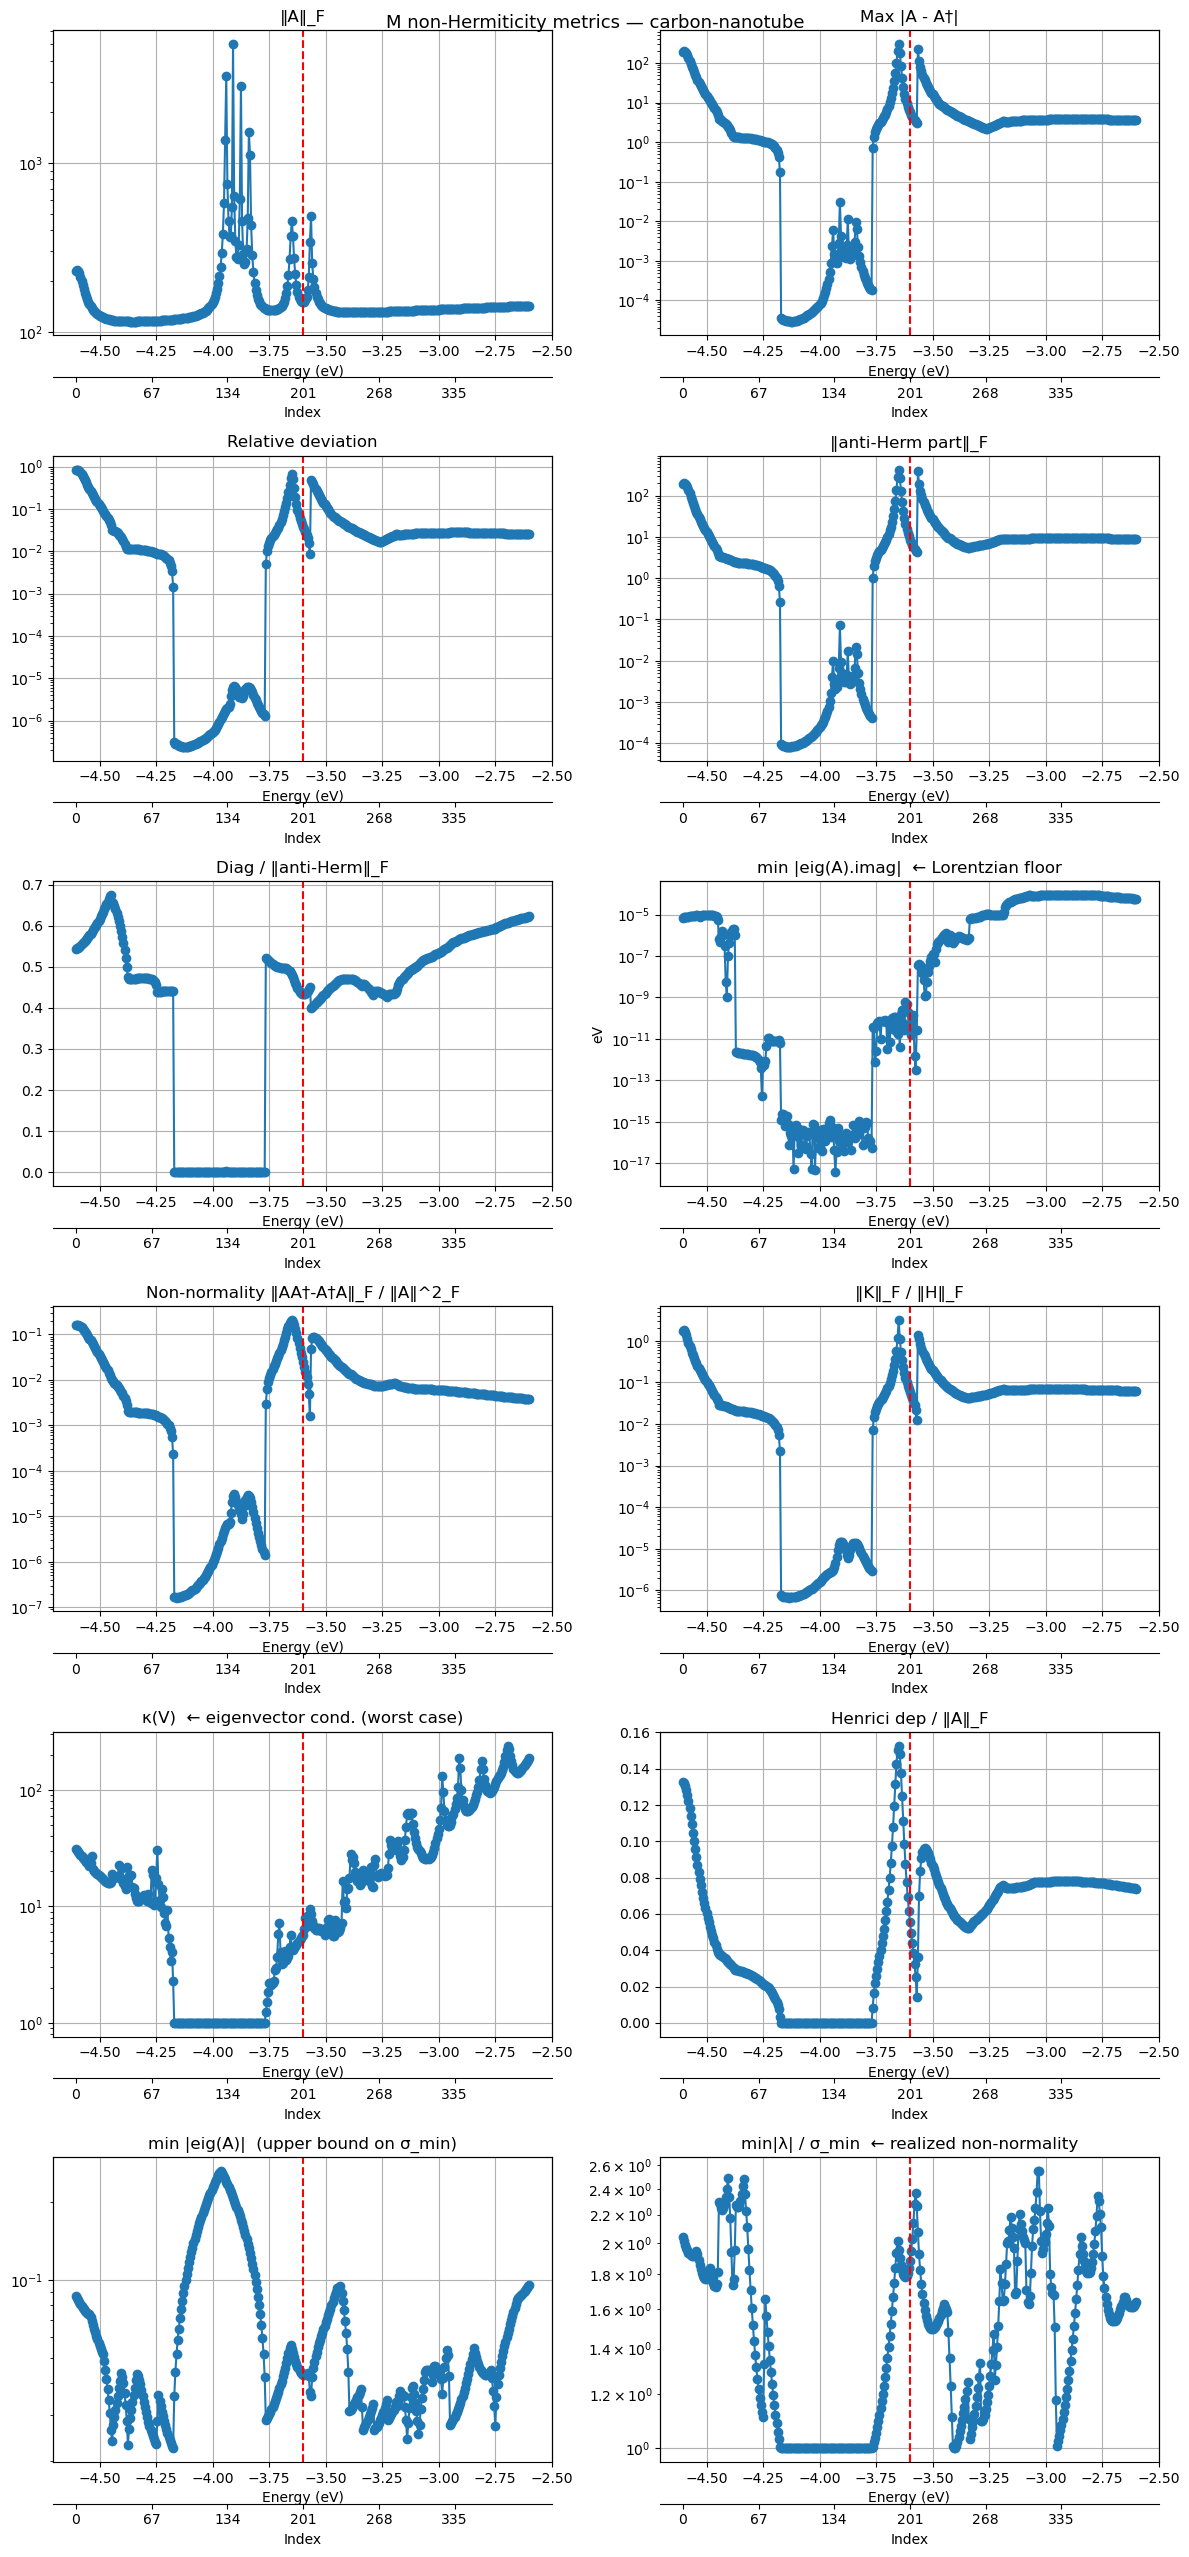

In [5]:
# Load σ_min array (already computed elsewhere)
min_singular_values_even, min_singular_values_uneven = np.load(folder / name / "min_singular_values_even.npy"), np.load(folder / name / "min_singular_values_uneven.npy")
min_singular_values = np.empty(len(min_singular_values_even) + len(min_singular_values_uneven), dtype=min_singular_values_even.dtype)
min_singular_values[0::2] = min_singular_values_even
min_singular_values[1::2] = min_singular_values_uneven

# Realized non-normality gap:  min|λ(A)| / σ_min(A)
min_abs_eig_arr = np.array([metrics[i]["min_abs_eig"] for i in indices])
eig_sigma_gap   = min_abs_eig_arr / (min_singular_values + 1e-300)

fig, axes = plt.subplots(6, 2, figsize=(12, 26))
fig.suptitle(f"M non-Hermiticity metrics — {name}", fontsize=13)

def _plot(ax, values, ylabel, title, logy=True):
    ax.plot(energies, values, "o-")
    ax.axvline(-3.6, color="red", linestyle="--", label="Conduction band edge")
    ax.set_title(title)
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel(ylabel)
    if logy and np.all(np.array(values) > 0):
        ax.set_yscale("log")
    ax.grid(True)
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    tick_energies = energies[::len(energies)//6]
    tick_indices  = idx_arr[::len(idx_arr)//6]
    ax2.set_xticks(tick_energies)
    ax2.set_xticklabels(tick_indices)
    ax2.set_xlabel("Index")
    ax2.xaxis.set_label_position("bottom")
    ax2.xaxis.tick_bottom()
    ax2.spines["bottom"].set_position(("outward", 30))

_plot(axes[0, 0], [metrics[i]["frob_A"]         for i in indices], "", "‖A‖_F")
_plot(axes[0, 1], [metrics[i]["max_dev"]        for i in indices], "", "Max |A - A†|")
_plot(axes[1, 0], [metrics[i]["rel_dev"]        for i in indices], "", "Relative deviation")
_plot(axes[1, 1], [metrics[i]["frob_antiherm"]  for i in indices], "", "‖anti-Herm part‖_F")
_plot(axes[2, 0], [metrics[i]["diag_ratio"]     for i in indices], "", "Diag / ‖anti-Herm‖_F", logy=False)
_plot(axes[2, 1], [metrics[i]["min_abs_A_imag"] for i in indices], "eV", "min |eig(A).imag|  ← Lorentzian floor")
_plot(axes[3, 0], [metrics[i]["non_normality"]  for i in indices], "", "Non-normality ‖AA†-A†A‖_F / ‖A‖^2_F")
_plot(axes[3, 1], [metrics[i]["ratio_KH"]       for i in indices], "", "‖K‖_F / ‖H‖_F")
_plot(axes[4, 0], [metrics[i]["kappa_V"]        for i in indices], "", "κ(V)  ← eigenvector cond. (worst case)")
_plot(axes[4, 1], [metrics[i]["dep_norm_rel"]   for i in indices], "", "Henrici dep / ‖A‖_F", logy=False)
_plot(axes[5, 0], min_abs_eig_arr, "", "min |eig(A)|  (upper bound on σ_min)")
_plot(axes[5, 1], eig_sigma_gap,   "", "min|λ| / σ_min  ← realized non-normality")

plt.tight_layout()
plt.savefig(f"M_metrics_{name}.png", dpi=150, bbox_inches="tight")
plt.show()

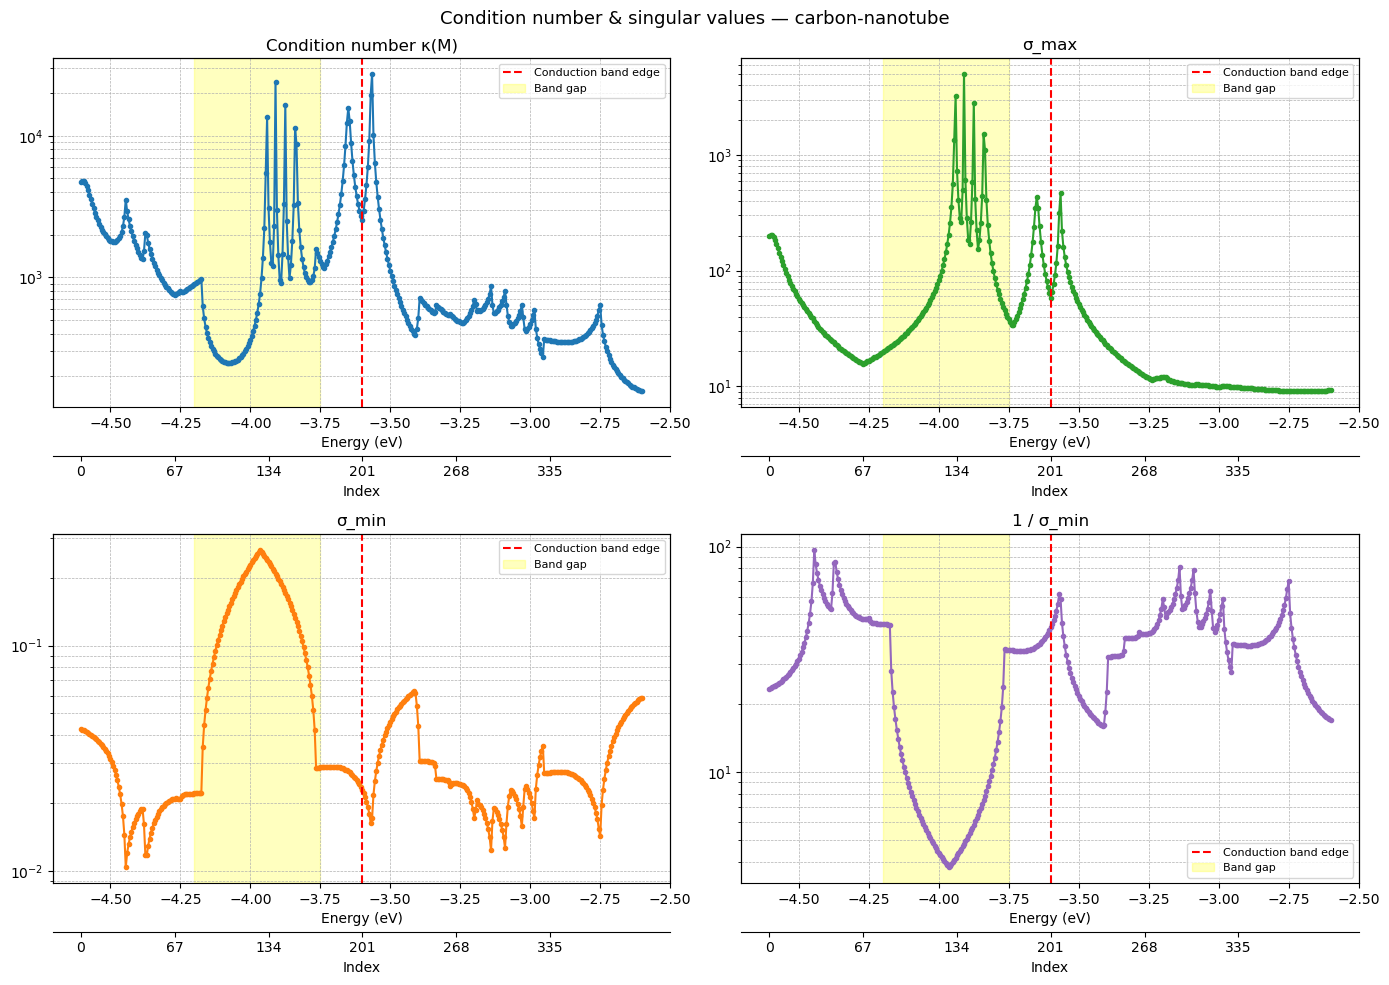

In [6]:
import matplotlib.ticker as ticker
folder = Path("/scratch/yimili/matrices")
name   = "carbon-nanotube"
#condition_numbers   = np.load(folder / name / "condition_full.npy")

max_singular_values_even = np.load(folder / name / "max_singular_values_even.npy")
max_singular_values_uneven = np.load(folder / name / "max_singular_values_uneven.npy")
min_singular_values_even = np.load(folder / name / "min_singular_values_even.npy")
min_singular_values_uneven = np.load(folder / name / "min_singular_values_uneven.npy")

max_singular_values = np.empty(len(max_singular_values_even) + len(max_singular_values_uneven), dtype=max_singular_values_even.dtype)
max_singular_values[0::2] = max_singular_values_even
max_singular_values[1::2] = max_singular_values_uneven

min_singular_values = np.empty(len(min_singular_values_even) + len(min_singular_values_uneven), dtype=min_singular_values_even.dtype)
min_singular_values[0::2] = min_singular_values_even
min_singular_values[1::2] = min_singular_values_uneven

condition_numbers = max_singular_values/min_singular_values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Condition number & singular values — {name}", fontsize=13)

def _plot_sv(ax, values, color, title):
    ax.plot(energies, values, "o-", markersize=3, color=color)
    ax.axvline(-3.6, color="red", linestyle="--", label="Conduction band edge")
    ax.axvspan(-4.2, -3.75, color="yellow", alpha=0.25, label="Band gap")
    ax.set_title(title)
    ax.set_xlabel("Energy (eV)")
    if np.all(np.array(values) > 0):
        ax.set_yscale("log")
    ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
    ax.yaxis.set_minor_locator(ticker.LogLocator(subs="all", numticks=20))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax.legend(fontsize=8)
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    step = max(1, len(energies) // 6)
    ax2.set_xticks(energies[::step])
    ax2.set_xticklabels(indices[::step])
    ax2.set_xlabel("Index")
    ax2.xaxis.set_label_position("bottom")
    ax2.xaxis.tick_bottom()
    ax2.spines["bottom"].set_position(("outward", 35))

_plot_sv(axes[0, 0], condition_numbers,          "tab:blue",   "Condition number κ(M)")
_plot_sv(axes[0, 1], max_singular_values,        "tab:green",  "σ_max")
_plot_sv(axes[1, 0], min_singular_values,        "tab:orange", "σ_min")
_plot_sv(axes[1, 1], 1.0 / min_singular_values, "tab:purple", "1 / σ_min")

plt.tight_layout()
plt.savefig(f"condition_svd_{name}.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
###############################################

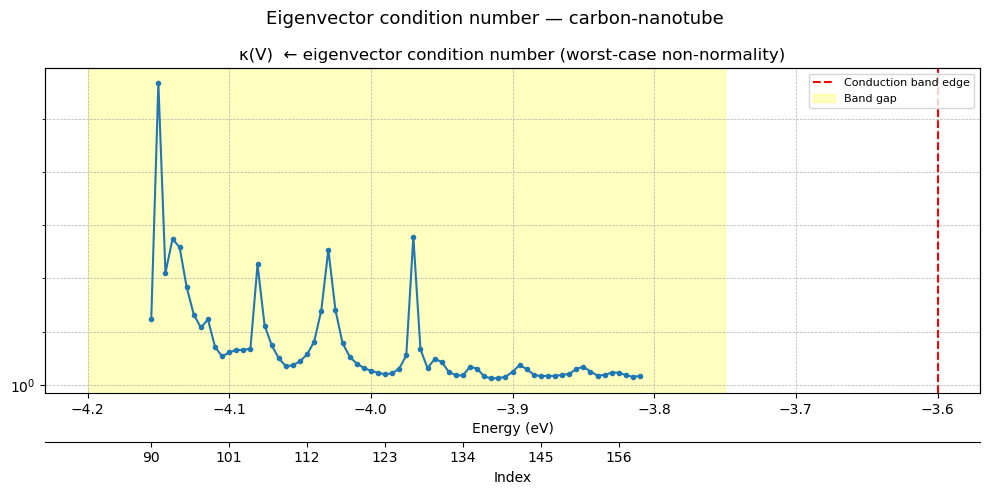

In [18]:
i_range  = np.array(list(range(90, 160)))
e_range  = -4.605 + 0.005 * i_range.astype(float)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(f"Eigenvector condition number — {name}", fontsize=13)

ax.plot(e_range, [metrics[i]["kappa_V"] for i in i_range], "o-", markersize=3, color="tab:blue")
ax.axvline(-3.6, color="red", linestyle="--", label="Conduction band edge")
ax.axvspan(-4.2, -3.75, color="yellow", alpha=0.25, label="Band gap")
ax.set_title("κ(V)  ← eigenvector condition number (worst-case non-normality)")
ax.set_xlabel("Energy (eV)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.yaxis.set_minor_locator(ticker.LogLocator(subs="all", numticks=20))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend(fontsize=8)

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
step = max(1, len(e_range) // 6)
ax2.set_xticks(e_range[::step])
ax2.set_xticklabels(i_range[::step])
ax2.set_xlabel("Index")
ax2.xaxis.set_label_position("bottom")
ax2.xaxis.tick_bottom()
ax2.spines["bottom"].set_position(("outward", 35))

plt.tight_layout()
plt.savefig(f"kappa_V_{name}.png", dpi=150, bbox_inches="tight")
plt.show()

# Why $\min_k |\lambda_k|$ is an upper bound on $\sigma_\min$

For any matrix $A \in \mathbb{C}^{n \times n}$, the smallest singular value is defined as:

$$\sigma_\min(A) = \min_{\|v\|=1} \|Av\|$$

Now take any eigenpair $(\lambda_k, v_k)$ with $\|v_k\| = 1$:

$$\|A v_k\| = \|\lambda_k v_k\| = |\lambda_k| \cdot \|v_k\| = |\lambda_k|$$

Since $\sigma_\min$ is the minimum over **all** unit vectors, and $v_k$ is one particular unit vector:

$$\sigma_\min(A) = \min_{\|v\|=1} \|Av\| \leq \|A v_k\| = |\lambda_k|$$

This holds for every $k$, so:

$$\boxed{\sigma_\min(A) \leq \min_k |\lambda_k(A)|}$$

## When is this tight?

For **normal** matrices ($AA^\dagger = A^\dagger A$), the SVD and eigendecomposition coincide:

$$A = U \Sigma V^\dagger = U \Sigma U^\dagger \quad \Rightarrow \quad \sigma_k = |\lambda_k|$$

so equality holds: $\sigma_\min = \min_k |\lambda_k|$.

For **non-normal** matrices, $V \neq U$ in general, and the worst-case stretch direction
is **not** an eigenvector. The gap is bounded by the eigenvector condition number $\kappa(V)$:

$$\frac{\min_k |\lambda_k|}{\kappa(V)} \leq \sigma_\min(A) \leq \min_k |\lambda_k|$$

The ratio you computed empirically:

$$\text{eig\_sigma\_gap} = \frac{\min_k |\lambda_k|}{\sigma_\min} \in [1, \kappa(V)]$$

measures how much of the worst-case non-normality damage is **actually realized**
at each energy $E$.

In [12]:
######################################

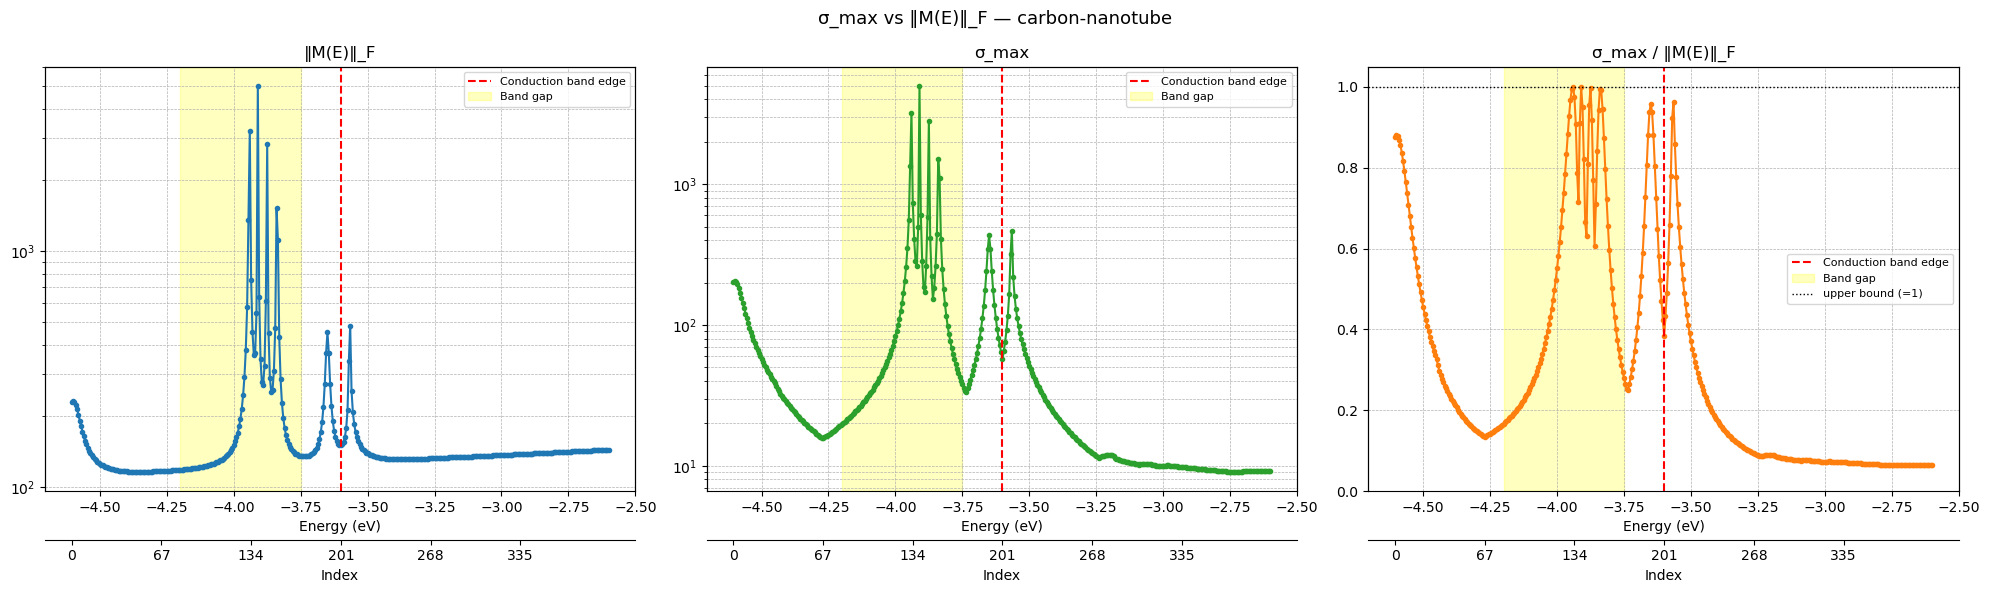

In [13]:
frob_A_arr  = np.array([metrics[i]["frob_A"] for i in indices])
ratio_arr   = max_singular_values / frob_A_arr

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f"σ_max vs ‖M(E)‖_F — {name}", fontsize=13)

def _plot_sv(ax, values, color, title):
    ax.plot(energies, values, "o-", markersize=3, color=color)
    ax.axvline(-3.6, color="red", linestyle="--", label="Conduction band edge")
    ax.axvspan(-4.2, -3.75, color="yellow", alpha=0.25, label="Band gap")
    ax.set_title(title)
    ax.set_xlabel("Energy (eV)")
    if np.all(np.array(values) > 0):
        ax.set_yscale("log")
    ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
    ax.yaxis.set_minor_locator(ticker.LogLocator(subs="all", numticks=20))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax.legend(fontsize=8)
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    step = max(1, len(energies) // 6)
    ax2.set_xticks(energies[::step])
    ax2.set_xticklabels(indices[::step])
    ax2.set_xlabel("Index")
    ax2.xaxis.set_label_position("bottom")
    ax2.xaxis.tick_bottom()
    ax2.spines["bottom"].set_position(("outward", 35))

_plot_sv(axes[0], frob_A_arr,      "tab:blue",   "‖M(E)‖_F")
_plot_sv(axes[1], max_singular_values, "tab:green",  "σ_max")

# ratio: linear scale since it's bounded in (0, 1]
ax = axes[2]
ax.plot(energies, ratio_arr, "o-", markersize=3, color="tab:orange")
ax.axvline(-3.6, color="red", linestyle="--", label="Conduction band edge")
ax.axvspan(-4.2, -3.75, color="yellow", alpha=0.25, label="Band gap")
ax.axhline(1.0, color="black", linestyle=":", linewidth=1, label="upper bound (=1)")
ax.set_title("σ_max / ‖M(E)‖_F")
ax.set_xlabel("Energy (eV)")
ax.set_ylim(0, 1.05)
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend(fontsize=8)
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
step = max(1, len(energies) // 6)
ax2.set_xticks(energies[::step])
ax2.set_xticklabels(indices[::step])
ax2.set_xlabel("Index")
ax2.xaxis.set_label_position("bottom")
ax2.xaxis.tick_bottom()
ax2.spines["bottom"].set_position(("outward", 35))

plt.tight_layout()
plt.savefig(f"sigma_max_vs_frob_{name}.png", dpi=150, bbox_inches="tight")
plt.show()